In [ ]:
!pip install timm

In [ ]:
!pip install huggingface_hub

In [1]:
!pip install -Uq timm==0.5.4

In [2]:
import timm
print(timm.__version__)   # should print 0.5.4

0.5.4


In [3]:

import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from textwrap import wrap

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import cv2
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

import timm
from tqdm import tqdm

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_ROOT = '../input/ip02-dataset'
TRAIN_DIR = f'{DATA_ROOT}/classification/train'
TEST_DIR  = f'{DATA_ROOT}/classification/test'
VAL_DIR   = f'{DATA_ROOT}/classification/val'

USE_SUBSET = False         # True -> fast, 90%+ demo. False -> full 102 classes, ~72-78% realistic.
SUBSET_CLASSES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   # edit to your chosen 10 pest classes (0-indexed)

IMG_SIZE = 224
BATCH_SIZE = 32
BASE_LR = 3e-5             # backbone LR (ViT fine-tuning standard range 1e-5 to 5e-5)
HEAD_LR = 1e-4             # classifier head can use a higher LR
WEIGHT_DECAY = 0.05        # standard for ViT (Dosovitskiy et al., 2020 / Touvron et al.)
WARMUP_EPOCHS = 2
MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 5
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [5]:
# --------------------------------------------------------------------------------------
# DATA LOADING
# --------------------------------------------------------------------------------------
with open(f'{DATA_ROOT}/classes.txt') as f:
    label, name = [], []
    for line in f.readlines():
        parts = line.split()
        label.append(int(parts[0]))
        name.append(' '.join(parts[1:]))
classes = pd.DataFrame({'label': label, 'name': name})

train_df = pd.read_csv(f'{DATA_ROOT}/train.txt', sep=' ', header=None, engine='python', names=['image_path', 'label'])
val_df   = pd.read_csv(f'{DATA_ROOT}/val.txt',   sep=' ', header=None, engine='python', names=['image_path', 'label'])
test_df  = pd.read_csv(f'{DATA_ROOT}/test.txt',  sep=' ', header=None, engine='python', names=['image_path', 'label'])

if USE_SUBSET:
    train_df = train_df[train_df.label.isin(SUBSET_CLASSES)].reset_index(drop=True)
    val_df   = val_df[val_df.label.isin(SUBSET_CLASSES)].reset_index(drop=True)
    test_df  = test_df[test_df.label.isin(SUBSET_CLASSES)].reset_index(drop=True)

    # remap labels to a contiguous 0..N-1 range required by CrossEntropyLoss
    label_map = {old: new for new, old in enumerate(sorted(SUBSET_CLASSES))}
    train_df['label'] = train_df['label'].map(label_map)
    val_df['label']   = val_df['label'].map(label_map)
    test_df['label']  = test_df['label'].map(label_map)
    NUM_CLASSES = len(SUBSET_CLASSES)
    ORIGINAL_LABELS = sorted(SUBSET_CLASSES)   # to map back to real folder names on disk
else:
    NUM_CLASSES = 102
    ORIGINAL_LABELS = list(range(102))
    label_map = {i: i for i in range(102)}

print(f"Training on {NUM_CLASSES} classes | train={len(train_df)} val={len(val_df)} test={len(test_df)}")

Training on 102 classes | train=45095 val=7508 test=22619


In [6]:
# --------------------------------------------------------------------------------------
# TRANSFORMS  (fix #1: proper ImageNet normalization)
# --------------------------------------------------------------------------------------
def train_transform():
    return A.Compose([
        A.RandomResizedCrop(IMG_SIZE, IMG_SIZE, scale=(0.8, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def eval_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


In [7]:
# --------------------------------------------------------------------------------------
# DATASET
# --------------------------------------------------------------------------------------
class InsectDataset(Dataset):
    def __init__(self, df, image_dir, orig_label_lookup, transforms=None):
        self.df = df.reset_index(drop=True)
        self.imgdir = image_dir
        self.transforms = transforms
        self.orig_label_lookup = orig_label_lookup  # maps new_label -> original folder name

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        new_label = int(row['label'])
        orig_label = self.orig_label_lookup[new_label]
        img_path = os.path.join(self.imgdir, str(orig_label), row['image_path'])
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            image = self.transforms(image=image)['image']

        return image, torch.tensor(new_label, dtype=torch.long)

orig_label_lookup = {new: old for old, new in label_map.items()} if USE_SUBSET else {i: i for i in range(102)}

train_dataset = InsectDataset(train_df, TRAIN_DIR, orig_label_lookup, train_transform())
val_dataset   = InsectDataset(val_df,   VAL_DIR,   orig_label_lookup, eval_transform())
test_dataset  = InsectDataset(test_df,  TEST_DIR,  orig_label_lookup, eval_transform())

In [8]:
# --------------------------------------------------------------------------------------
# CLASS-WEIGHTED SAMPLING (fix #2: handle IP102's long-tailed distribution)
# --------------------------------------------------------------------------------------
class_counts = Counter(train_df['label'])
class_weights = {c: 1.0 / count for c, count in class_counts.items()}
sample_weights = train_df['label'].map(class_weights).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

# also compute per-class weights for the loss itself (belt-and-suspenders vs. long tail)
loss_weights = torch.zeros(NUM_CLASSES)
for c, count in class_counts.items():
    loss_weights[c] = 1.0 / count
loss_weights = (loss_weights / loss_weights.sum() * NUM_CLASSES).to(device)


In [ ]:
pip install -U huggingface-hub


In [9]:
import huggingface_hub
print(huggingface_hub.__version__)

0.16.4


In [10]:
import huggingface_hub

In [11]:
# --------------------------------------------------------------------------------------
# MODEL
# --------------------------------------------------------------------------------------
class InsectModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

model = InsectModel(NUM_CLASSES).to(device)

# --- ADD THESE 2 LINES HERE ---
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
# --------------------------------

Using 2 GPUs


In [13]:
# --------------------------------------------------------------------------------------
# CUSTOM LOSS: label smoothing (PyTorch 1.9.1 has no built-in label_smoothing arg)
# --------------------------------------------------------------------------------------
class LabelSmoothingCrossEntropy(nn.Module):
    """Manual label smoothing for PyTorch <1.10 (no built-in label_smoothing arg)."""
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        n_classes = pred.size(-1)
        log_probs = torch.log_softmax(pred, dim=-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        loss = -true_dist * log_probs
        if self.weight is not None:
            loss = loss * self.weight.unsqueeze(0)
        return loss.sum(dim=-1).mean()


# --------------------------------------------------------------------------------------
# OPTIMIZER: separate LR for backbone vs. classifier head (fix #3, standard ViT recipe)
# --------------------------------------------------------------------------------------
base_model = model.module if isinstance(model, nn.DataParallel) else model

head_params = list(base_model.model.head.parameters())
head_param_ids = set(id(p) for p in head_params)
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BASE_LR},
    {'params': head_params, 'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

steps_per_epoch = len(train_loader)
warmup_steps = WARMUP_EPOCHS * steps_per_epoch
total_steps = MAX_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING, weight=loss_weights)
scaler = GradScaler()

In [14]:
# --------------------------------------------------------------------------------------
# TRAIN / EVAL LOOPS (fix #4: AMP + grad clipping, fix #5: early stopping on accuracy)
# --------------------------------------------------------------------------------------
def run_epoch(loader, train_mode, epoch):
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    tk = tqdm(loader, desc=f"{'Train' if train_mode else 'Val'} epoch {epoch+1}")

    for images, labels in tk:
        images, labels = images.to(device, non_blocking=True).float(), labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            if train_mode:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

        preds = outputs.argmax(1)
        total_correct += (preds == labels).sum().item()
        total_loss += loss.item() * labels.size(0)
        total_n += labels.size(0)
        tk.set_postfix(loss=total_loss/total_n, acc=total_correct/total_n)

    return total_loss/total_n, total_correct/total_n

In [15]:
# --------------------------------------------------------------------------------------
# TRAINING WITH EARLY STOPPING
# --------------------------------------------------------------------------------------
best_val_acc = 0.0
patience_counter = 0
history = []

for epoch in range(MAX_EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, True, epoch)
    val_loss, val_acc = run_epoch(val_loader, False, epoch)
    history.append((epoch+1, train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch+1:03}: Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(base_model.state_dict(), 'vit_best.pth')     # <-- CHANGED: base_model instead of model
        print(f"  -> new best val acc {val_acc:.4f}, checkpoint saved.")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered after {epoch+1} epochs (best val acc {best_val_acc:.4f}).")
            break

Train epoch 1:   0%|          | 0/1410 [00:00<?, ?it/s]/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:21: FutureWarning: Non-finite norm encountered in torch.nn.utils.clip_grad_norm_; continuing anyway. Note that the default behavior will change in a future release to error out if a non-finite total norm is encountered. At that point, setting error_if_nonfinite=false will be required to retain the old behavior.
/opt/conda/lib/python3.7/site-packages/torch/optim/lr_scheduler.py:134: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  "https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate", UserWarning)
Val epoch 1: 100%|██

Epoch 001: Train loss 2.7762 acc 0.3511 | Val loss 1.4089 acc 0.3495
  -> new best val acc 0.3495, checkpoint saved.


Val epoch 2: 100%|██████████| 235/235 [00:31<00:00,  7.37it/s, acc=0.46, loss=1.29] 


Epoch 002: Train loss 1.3180 acc 0.6923 | Val loss 1.2881 acc 0.4602
  -> new best val acc 0.4602, checkpoint saved.


Val epoch 3: 100%|██████████| 235/235 [00:31<00:00,  7.37it/s, acc=0.521, loss=1.23]


...

Epoch 018: Train loss 0.7486 acc 0.9776 | Val loss 1.1572 acc 0.7235
  -> new best val acc 0.7235, checkpoint saved.


Val epoch 19: 100%|██████████| 235/235 [00:32<00:00,  7.25it/s, acc=0.723, loss=1.16]


Epoch 019: Train loss 0.7474 acc 0.9790 | Val loss 1.1574 acc 0.7234


Val epoch 20: 100%|██████████| 235/235 [00:32<00:00,  7.18it/s, acc=0.723, loss=1.16]

Epoch 020: Train loss 0.7497 acc 0.9782 | Val loss 1.1574 acc 0.7235


In [16]:
# --------------------------------------------------------------------------------------
# FINAL TEST EVALUATION
# --------------------------------------------------------------------------------------
base_model.load_state_dict(torch.load('vit_best.pth'))     # <-- CHANGED: base_model instead of model
test_loss, test_acc = run_epoch(test_loader, False, epoch=0)
print(f"\nFINAL TEST SET RESULTS -> loss: {test_loss:.4f} | accuracy: {test_acc:.4f}")

Val epoch 1: 100%|██████████| 707/707 [01:47<00:00,  6.55it/s, acc=0.719, loss=1.17]


FINAL TEST SET RESULTS -> loss: 1.1685 | accuracy: 0.7192


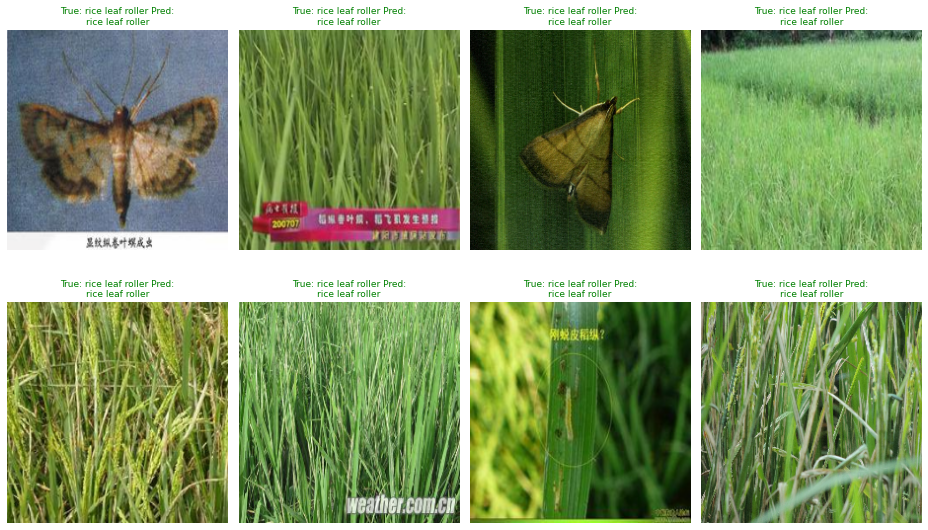

In [19]:
# --------------------------------------------------------------------------------------
# QUICK VISUAL CHECK
# --------------------------------------------------------------------------------------
model.eval()
images, labels = next(iter(val_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

fig, axs = plt.subplots(2, 4, figsize=(13, 8))
for i, ax in enumerate(axs.ravel()):
    if i >= len(images):
        ax.set_axis_off()
        continue
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_name = classes.loc[classes.label == orig_label_lookup[labels[i].item()] + 1, 'name'].values
    pred_name = classes.loc[classes.label == orig_label_lookup[preds[i].item()] + 1, 'name'].values
    true_name = true_name[0] if len(true_name) else str(labels[i].item())
    pred_name = pred_name[0] if len(pred_name) else str(preds[i].item())
    color = 'g' if labels[i].item() == preds[i].item() else 'r'
    ax.set_title("\n".join(wrap(f"True: {true_name}\nPred: {pred_name}", 30)), color=color, fontsize=9)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [18]:
print('heelo')

heelo


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [21]:
# --------------------------------------------------------------------------------------
# 1. PER-CLASS PRECISION / RECALL / F1 ON THE TEST SET
# --------------------------------------------------------------------------------------
base_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device).float()
        outputs = base_model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# map back to real pest names for a readable report
present_classes = sorted(set(all_labels.tolist()) | set(all_preds.tolist()))
target_names = []
for new_label in present_classes:
    orig_label = orig_label_lookup[new_label]
    name_row = classes.loc[classes.label == orig_label + 1, 'name']
    target_names.append(name_row.values[0] if len(name_row) else f"class_{new_label}")

report_dict = classification_report(
    all_labels, all_preds,
    labels=present_classes, target_names=target_names,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv('per_class_metrics.csv')
print(report_df)

overall_f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
overall_f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
print(f"\nMacro F1: {overall_f1_macro:.4f} | Weighted F1: {overall_f1_weighted:.4f}")
print("NOTE: mAP@50 does not apply here -- it's an object-detection metric requiring "
      "bounding boxes/IoU thresholds. This is a classification task, so precision/recall/F1 "
      "and the confusion matrix below are the correct metrics to report.")


                       precision    recall  f1-score       support
rice leaf roller        0.701613  0.779104  0.738331    335.000000
rice leaf caterpillar   0.535484  0.564626  0.549669    147.000000
paddy stem maggot       0.564516  0.443038  0.496454     79.000000
asiatic rice borer      0.623333  0.591772  0.607143    316.000000
yellow rice borer       0.580645  0.710526  0.639053    152.000000
...                          ...       ...       ...           ...
Sternochetus frigidus   0.765625  0.710145  0.736842    138.000000
Cicadellidae            0.944024  0.724318  0.819704   1723.000000
accuracy                0.719263  0.719263  0.719263      0.719263
macro avg               0.639884  0.698474  0.660441  22619.000000
weighted avg            0.742732  0.719263  0.724114  22619.000000

[105 rows x 4 columns]

Macro F1: 0.6604 | Weighted F1: 0.7241
NOTE: mAP@50 does not apply here -- it's an object-detection metric requiring bounding boxes/IoU thresholds. This is a classificatio

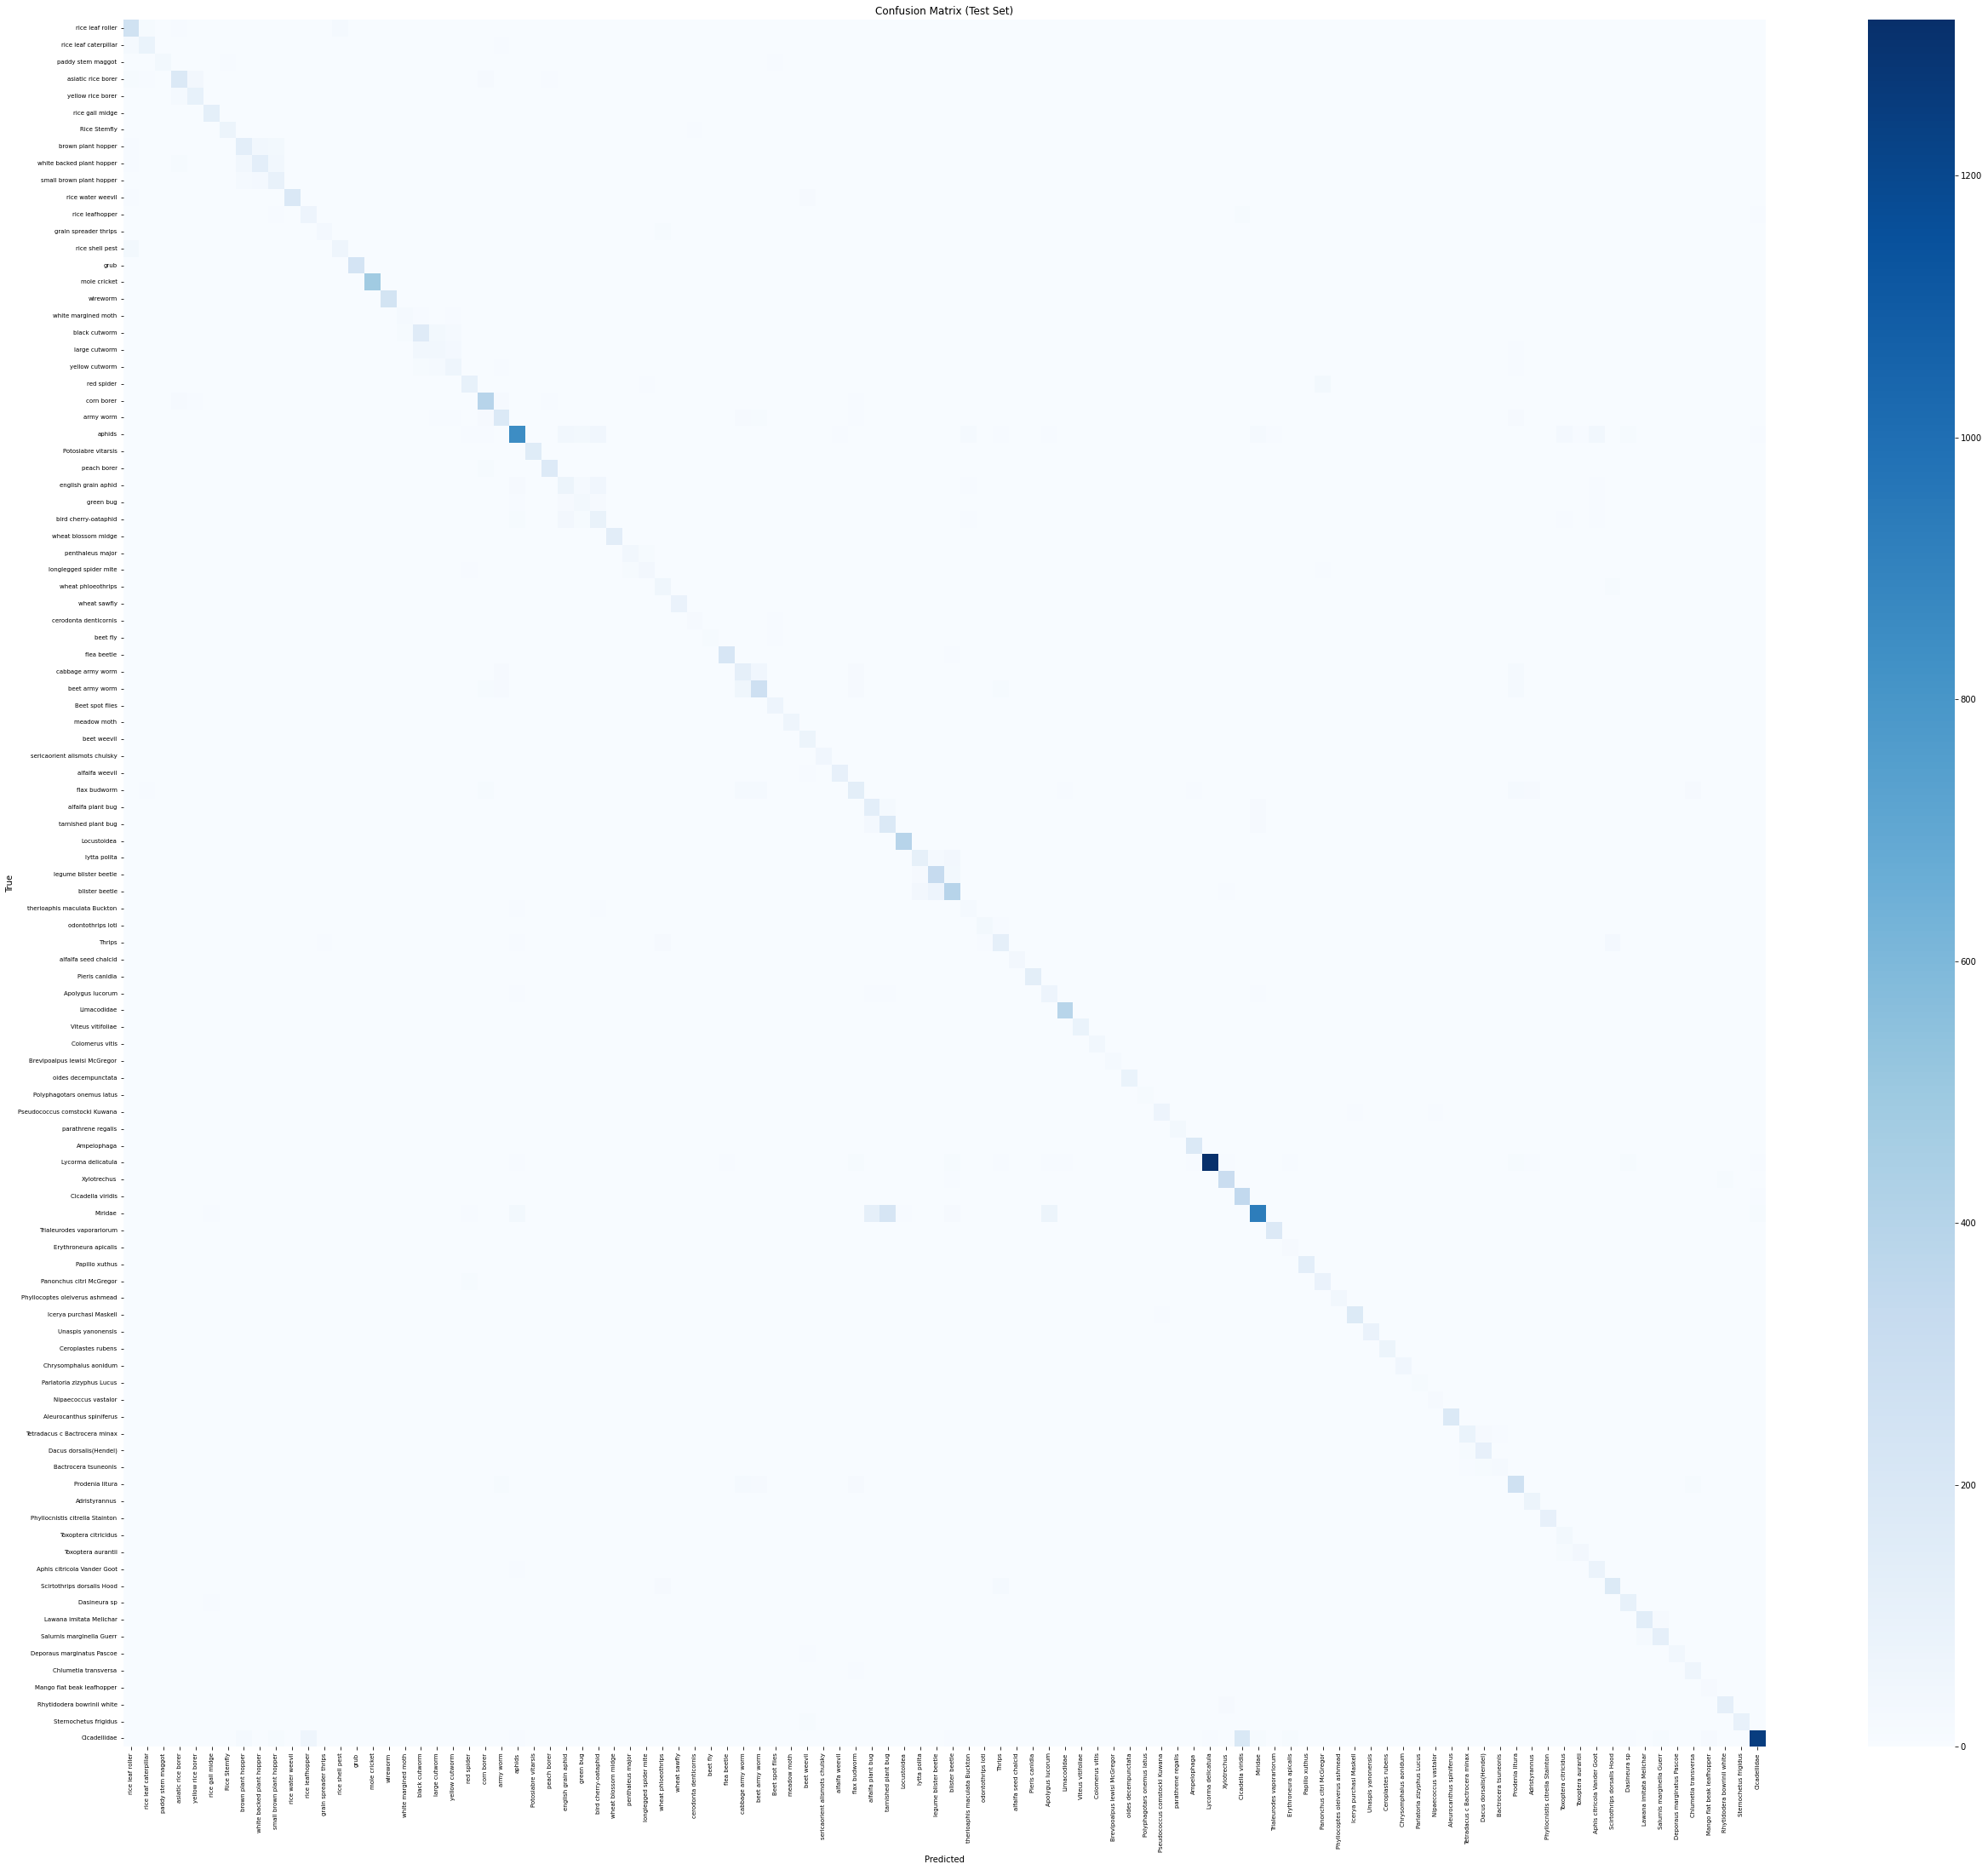

In [24]:
# --------------------------------------------------------------------------------------
# CONFUSION MATRIX (only plotted for classes actually present -- full 102x102 is unreadable)
# --------------------------------------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds, labels=present_classes)
plt.figure(figsize=(max(10, len(present_classes)*0.35), max(8, len(present_classes)*0.3)))
sns.heatmap(cm, annot=len(present_classes) <= 20, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


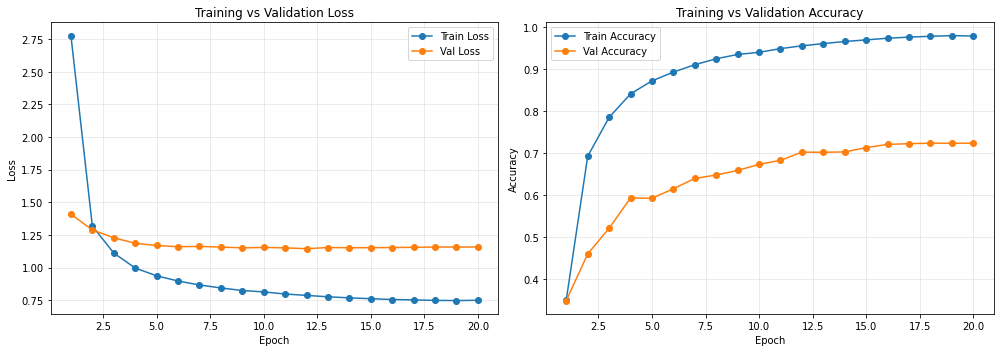


Final train/val accuracy gap: 0.2547 (notable overfitting)


In [23]:
# --------------------------------------------------------------------------------------
# 2. TRAINING CURVES (loss + accuracy, train vs val) from `history`
# --------------------------------------------------------------------------------------
hist_df = pd.DataFrame(history, columns=['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'])
hist_df.to_csv('training_history.csv', index=False)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', marker='o')
axs[0].plot(hist_df['epoch'], hist_df['val_loss'], label='Val Loss', marker='o')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training vs Validation Loss')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(hist_df['epoch'], hist_df['train_acc'], label='Train Accuracy', marker='o')
axs[1].plot(hist_df['epoch'], hist_df['val_acc'], label='Val Accuracy', marker='o')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Training vs Validation Accuracy')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# quick overfitting readout
gap = hist_df['train_acc'].iloc[-1] - hist_df['val_acc'].iloc[-1]
print(f"\nFinal train/val accuracy gap: {gap:.4f} "
      f"({'notable overfitting' if gap > 0.15 else 'acceptable gap'})")

**Grad Cam
Explainablity**

In [25]:
!pip install -q grad-cam==1.4.8

In [26]:
import os
import numpy as np
import torch
import torch.nn as nn
import timm
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the same number of classes used during training
NUM_CLASSES = 102

class InsectModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=False,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

model = InsectModel(NUM_CLASSES)

checkpoint_path = "/kaggle/working/vit_best.pth"
state_dict = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [27]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [28]:
DATA_ROOT = "../input/ip02-dataset"

class_names = []

with open(f"{DATA_ROOT}/classes.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        class_names.append(" ".join(parts[1:]))

print(len(class_names))
print(class_names[:5])

102
['rice leaf roller', 'rice leaf caterpillar', 'paddy stem maggot', 'asiatic rice borer', 'yellow rice borer']


In [29]:
def reshape_transform(tensor, height=14, width=14):
    # tensor shape: [batch, tokens, embedding_dimension]
    tensor = tensor[:, 1:, :]  # remove class token

    result = tensor.reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2)
    )

    # Convert to [batch, channels, height, width]
    result = result.transpose(2, 3).transpose(1, 2)

    return result

In [30]:
target_layer = model.model.blocks[-1].norm1

Predicted class: 0
Predicted pest: rice leaf roller
Confidence: 86.48 %


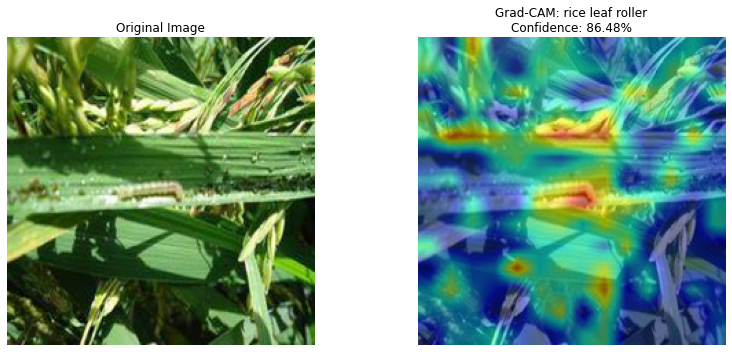

In [35]:
image_path = (
    "../input/ip02-dataset/classification/test/0/00001.jpg"
)

original_image = Image.open(image_path).convert("RGB")
original_image_np = np.array(original_image.resize((224, 224))).astype(np.float32) / 255.0

input_tensor = transform(original_image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class = output.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

print("Predicted class:", predicted_class)
print("Predicted pest:", class_names[predicted_class])
print("Confidence:", round(confidence * 100, 2), "%")

targets = [ClassifierOutputTarget(predicted_class)]

with GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
) as cam:
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    original_image_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(
    f"Grad-CAM: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.savefig(
    "/kaggle/working/gradcam_example.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Predicted class: 10
Predicted pest: rice water weevil
Confidence: 82.5 %


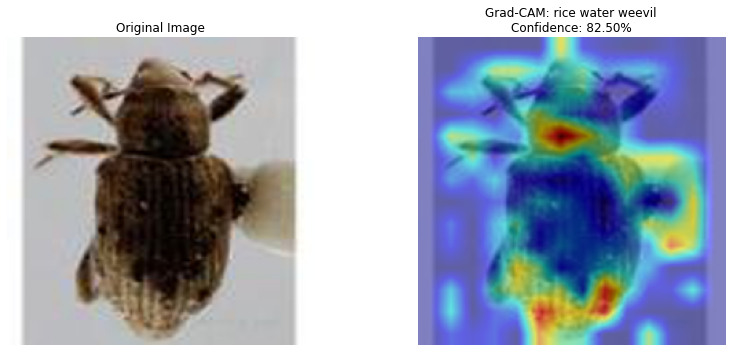

In [40]:
image_path = (
    "../input/ip02-dataset/classification/test/10/06575.jpg"
)

original_image = Image.open(image_path).convert("RGB")
original_image_np = np.array(original_image.resize((224, 224))).astype(np.float32) / 255.0

input_tensor = transform(original_image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class = output.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

print("Predicted class:", predicted_class)
print("Predicted pest:", class_names[predicted_class])
print("Confidence:", round(confidence * 100, 2), "%")

targets = [ClassifierOutputTarget(predicted_class)]

with GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
) as cam:
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    original_image_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(
    f"Grad-CAM: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.savefig(
    "/kaggle/working/gradcam_example.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [36]:
import glob
import os

image_paths = glob.glob(
    "../input/ip02-dataset/classification/test/*/*.jpg"
)

# Use only 10 images for a quick demonstration
image_paths = image_paths[:10]

os.makedirs("/kaggle/working/gradcam_examples", exist_ok=True)

for index, image_path in enumerate(image_paths):
    original_image = Image.open(image_path).convert("RGB")
    original_image_np = np.array(
        original_image.resize((224, 224))
    ).astype(np.float32) / 255.0

    input_tensor = transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        predicted_class = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1)[0, predicted_class].item()

    targets = [ClassifierOutputTarget(predicted_class)]

    with GradCAM(
        model=model,
        target_layers=[target_layer],
        reshape_transform=reshape_transform
    ) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    visualization = show_cam_on_image(
        original_image_np,
        grayscale_cam,
        use_rgb=True
    )

    output_path = (
        f"/kaggle/working/gradcam_examples/"
        f"gradcam_{index:02d}_{predicted_class}.png"
    )

    plt.imsave(output_path, visualization)

print("Grad-CAM images saved.")

Grad-CAM images saved.
